# Homework 3 Problem 3 Template

# Problem 2

In [3]:
%%capture
!pip install DataSynthesizer

In [4]:
import numpy as np
import pandas as pd
np.random.seed(0)

from DataSynthesizer.DataDescriber import DataDescriber
from DataSynthesizer.DataGenerator import DataGenerator
from DataSynthesizer.ModelInspector import ModelInspector
from DataSynthesizer.lib.utils import normalize_given_distribution, read_json_file, pairwise_attributes_mutual_information, mutual_information, set_random_seed

from IPython.display import clear_output
from scipy.stats import entropy, ks_2samp
from scipy.spatial.distance import euclidean
from sklearn.metrics import mutual_info_score
from random import randint
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
import DataSynthesizer.DataGenerator as dg
dg.np = np

In [6]:
def generate_data_A(input_data_file, output_data_size, seed=None):
    seed = seed or randint(0, 2**30)
    description_file = description_files['A']

    describer = DataDescriber()
    describer.describe_dataset_in_random_mode(input_data_file, seed=seed)
    describer.save_dataset_description_to_file(description_file)

    generator = DataGenerator()
    generator.generate_dataset_in_random_mode(output_data_size, description_file, seed=seed)
    return generator.synthetic_dataset

In [7]:
def generate_data_B(input_data_file, output_data_size, epsilon=0.1, seed=None):
    seed = seed or randint(0, 2**30)
    description_file = description_files['B']

    describer = DataDescriber()
    describer.describe_dataset_in_independent_attribute_mode(input_data_file, epsilon=epsilon, seed=seed)
    describer.save_dataset_description_to_file(description_file)

    generator = DataGenerator()
    generator.generate_dataset_in_independent_mode(output_data_size, description_file, seed=seed)
    return generator.synthetic_dataset

In [8]:
def generate_data_CD(input_data_file, output_data_size, description_file, epsilon=0.5, k=1, seed=None):
    seed = seed or randint(0, 2**30)

    describer = DataDescriber()
    describer.describe_dataset_in_correlated_attribute_mode(input_data_file, k=k, epsilon=epsilon, seed=seed)
    describer.save_dataset_description_to_file(description_file)

    generator = DataGenerator()
    generator.generate_dataset_in_correlated_attribute_mode(output_data_size, description_file, seed=seed)
    return generator.synthetic_dataset

def generate_data_C(input_data_file, output_data_size, epsilon=0.1, seed=None):
    return generate_data_CD(input_data_file, output_data_size, description_files['C'], epsilon, k=1, seed=seed)

def generate_data_D(input_data_file, output_data_size, epsilon=0.1, seed=None):
    return generate_data_CD(input_data_file, output_data_size, description_files['D'], epsilon, k=2, seed=seed)

Start with a real dataset __hw_compas__ and a fake dataset __hw_fake__. Generate synthetic datasets of size __N=10000__, in the following four categories:
- A:  random mode
- B: independent attribute mode with __epsilon = 0.1__
- C:  correlated attribute mode with __epsilon = 0.1__, Bayes net degree k=1
- D: correlated attribute mode with __epsilon = 0.1__, Bayes net degree k=2

**If using Google Colab:** Upload `hw_compas.csv` and `hw_fake.csv` to the Files directory.

In [9]:
real_data_file = 'hw_compas.csv'
fake_data_file = 'hw_fake.csv'

In [10]:
output_data_size = 10000
epsilon = 0.1

seed = 0  # make the entire notebook reproducible

description_files = {'A': './descrption_A.json',
                     'B': './descrption_B.json',
                     'C': './descrption_C.json',
                     'D': './descrption_D.json'}

set_random_seed(seed)

df_real_A = generate_data_A(real_data_file, output_data_size)
df_real_B = generate_data_B(real_data_file, output_data_size, epsilon=epsilon)
df_real_C = generate_data_C(real_data_file, output_data_size, epsilon=epsilon)
df_real_D = generate_data_D(real_data_file, output_data_size, epsilon=epsilon)

df_fake_A = generate_data_A(fake_data_file, output_data_size)
df_fake_B = generate_data_B(fake_data_file, output_data_size, epsilon=epsilon)
df_fake_C = generate_data_C(fake_data_file, output_data_size, epsilon=epsilon)
df_fake_D = generate_data_D(fake_data_file, output_data_size, epsilon=epsilon)

clear_output()

## Part (a)

### Q1

Median, Mean, Min, Max of __age__ and __score__ for each A, B, C and D, compare to the ground truth value in __hw_compas__, present results in a table

In [11]:
df_real = pd.read_csv(real_data_file)
df_fake = pd.read_csv(fake_data_file)

print(df_real["age"].describe())
print(df_real["score"].describe())

count    11757.000000
mean        35.143319
std         12.022894
min         18.000000
25%         25.000000
50%         32.000000
75%         43.000000
max         96.000000
Name: age, dtype: float64
count    11757.000000
mean         4.371268
std          2.877598
min         -1.000000
25%          2.000000
50%          4.000000
75%          7.000000
max         10.000000
Name: score, dtype: float64


In [12]:
# Your code here

print("df_real_A")
print(df_real_A['age'].describe())
print(df_real_A['score'].describe())

print("df_real_B")
print(df_real_B['age'].describe())
print(df_real_B['score'].describe())

print("df_real_C")
print(df_real_C['age'].describe())
print(df_real_C['score'].describe())

print("df_real_D")
print(df_real_D['age'].describe())
print(df_real_D['score'].describe())

df_real_A
count    10000.000000
mean        50.173100
std         29.283499
min          0.000000
25%         25.000000
50%         51.000000
75%         76.000000
max        100.000000
Name: age, dtype: float64
count    10000.000000
mean         4.939200
std          3.357682
min         -1.000000
25%          2.000000
50%          5.000000
75%          8.000000
max         10.000000
Name: score, dtype: float64
df_real_B
count    10000.00000
mean        35.73540
std         12.56577
min         18.00000
25%         26.00000
50%         33.00000
75%         44.00000
max         76.00000
Name: age, dtype: float64
count    10000.000000
mean         4.365700
std          2.842107
min          1.000000
25%          2.000000
50%          4.000000
75%          7.000000
max         10.000000
Name: score, dtype: float64
df_real_C
count    10000.000000
mean        41.578800
std         18.143266
min         18.000000
25%         27.000000
50%         36.000000
75%         52.000000
max         

### Q2

Some more sophisticated statistical measure that’s good for independent attribute mode - __Two-sample Kolmogorov–Smirnov test__ and __KL-divergence__. Also show the difference visually, comparing real vs. synthetic

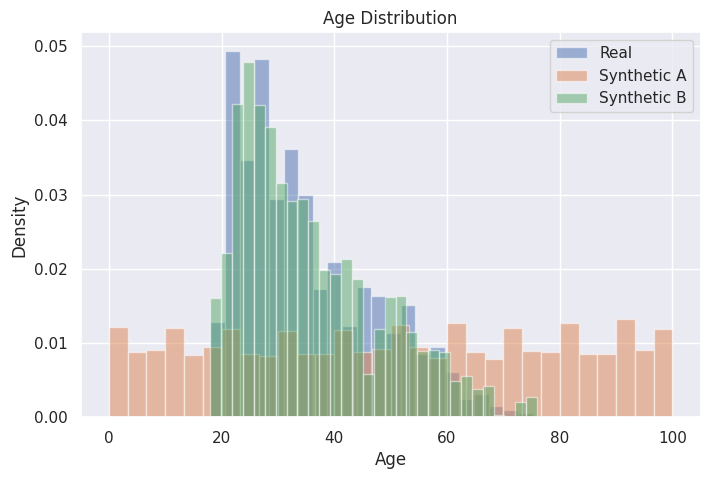

In [13]:
# Your code here
plt.figure(figsize=(8, 5))

plt.hist(df_real["age"], bins=30, alpha=0.5, density=True, label="Real")
plt.hist(df_real_A["age"], bins=30, alpha=0.5, density=True, label="Synthetic A")
plt.hist(df_real_B["age"], bins=30, alpha=0.5, density=True, label="Synthetic B")


plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.show()

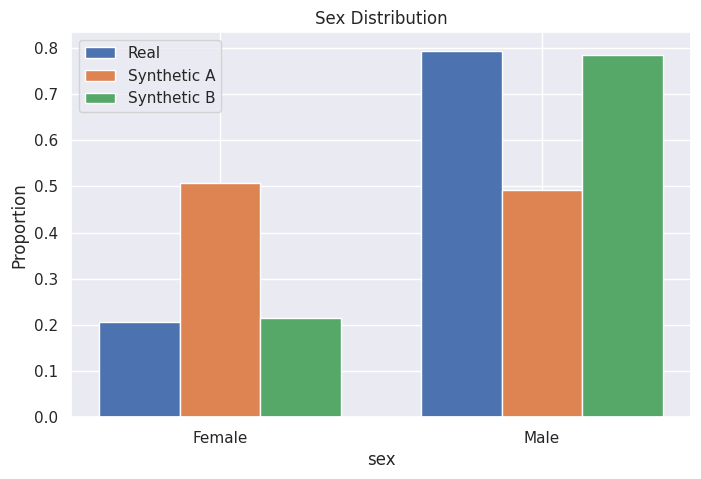

In [14]:
real_dist = df_real["sex"].value_counts(normalize=True)
A_dist = df_real_A["sex"].value_counts(normalize=True)
B_dist = df_real_B["sex"].value_counts(normalize=True)

all_categories = sorted(set(real_dist.index) | set(A_dist.index) | set(B_dist.index))

real_vals = [real_dist.get(cat, 0) for cat in all_categories]
A_vals = [A_dist.get(cat, 0) for cat in all_categories]
B_vals = [B_dist.get(cat, 0) for cat in all_categories]

x = np.arange(len(all_categories))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, real_vals, width, label="Real")
plt.bar(x, A_vals, width, label="Synthetic A")
plt.bar(x + width, B_vals, width, label="Synthetic B")

plt.xticks(x, all_categories)
plt.xlabel("sex")
plt.ylabel("Proportion")
plt.title("Sex Distribution")
plt.legend()
plt.show()

#### Two-sample Kolmogorov–Smirnov test for continous attributes

In [15]:
def ks_test(df_in: pd.DataFrame, df_out: pd.DataFrame, attr: str):
    """
    df_in: the sensitive dataset
    df_out: the synthetic dataset
    attr: the attribute that will be calculated for Two-sample Kolmogorov–Smirnov test.
    """
    return ks_2samp(df_in[attr], df_out[attr])[0]

In [16]:
ks_A = ks_test(df_real, df_real_A, "age")
ks_B = ks_test(df_real, df_real_B, "age")


print("KS test for age:")
print(f"A: {ks_A}")
print(f"B: {ks_B}")

KS test for age:
A: 0.3735091775112699
B: 0.026252445351705345


#### KL-divergence for categorical attributes

In [17]:
def get_distribution_of_categorical_attribute(attribute: pd.Series, indicies=None):
    distribution = attribute.dropna().value_counts()
    if indicies is not None:
        for idx in set(indicies) - set(distribution.index):
            distribution.loc[idx] = 0
    distribution.sort_index(inplace=True)
    return distribution/sum(distribution)

def kl_test(df_in: pd.DataFrame, df_out: pd.DataFrame, attr: str):
    """
    df_in: the sensitive dataset
    df_out: the synthetic dataset
    attr: the attribute that will be calculated for KL-divergence.
    """
    distribution_in = get_distribution_of_categorical_attribute(df_in[attr])
    distribution_out = get_distribution_of_categorical_attribute(df_out[attr], distribution_in.index)
    return entropy(distribution_out, distribution_in)

In [18]:
kl_A = kl_test(df_real, df_real_A, "sex")
kl_B = kl_test(df_real, df_real_B, "sex")

print("KL divergence for sex:")
print(f"A: {kl_A:.4f}")
print(f"B: {kl_B:.4f}")

KL divergence for sex:
A: 0.2232
B: 0.0002


### Q3

In [19]:
# Use pairwise_attributes_mutual_information function.
# For function parameters, refer to https://github.com/DataResponsibly/DataSynthesizer/blob/master/DataSynthesizer/lib/utils.py#L31
# Your code here

mi_fake = pairwise_attributes_mutual_information(df_fake)
mi_fake_C = pairwise_attributes_mutual_information(df_fake_C)
mi_fake_D = pairwise_attributes_mutual_information(df_fake_D)

In [20]:
print(mi_fake)

           child_1   child_2  parent_1  parent_2
child_1   1.000000  0.211242  0.214345  0.195899
child_2   0.211242  1.000000  0.208301  0.200690
parent_1  0.214345  0.208301  1.000000  0.002421
parent_2  0.195899  0.200690  0.002421  1.000000


In [23]:
# Use can sns.heatmap for pairwise mutual information
# For examples, refer to https://seaborn.pydata.org/generated/seaborn.heatmap.html
# Your code here
def plot_heatmap(corr):
  mask = np.triu(np.ones_like(corr, dtype=bool))

  f, ax = plt.subplots(figsize=(6, 5))

  cmap = sns.diverging_palette(230, 20, as_cmap=True)

  sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, vmin = 0, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

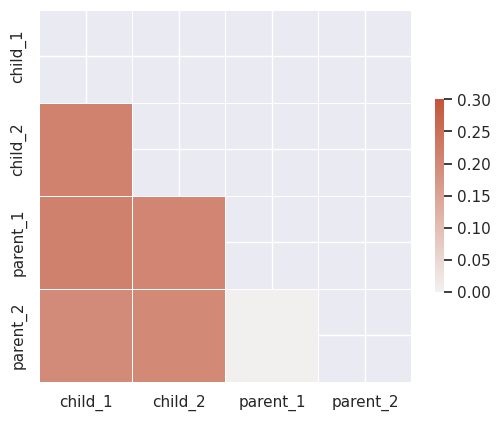

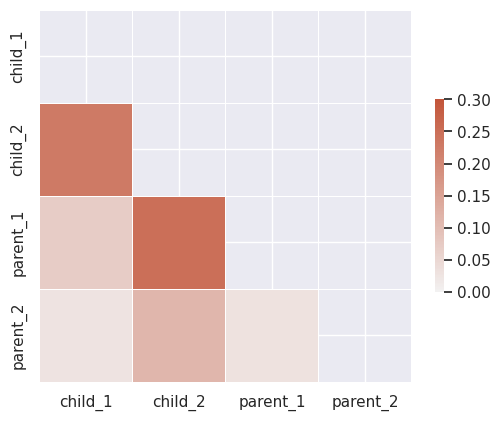

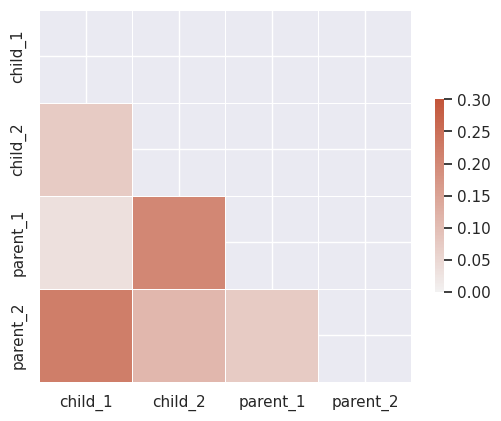

In [24]:
plot_heatmap(mi_fake)
plot_heatmap(mi_fake_C)
plot_heatmap(mi_fake_D)

## Part (b)

Study the variability in accuracy of answers to Q1 and Q2 for A, B and C: fix epsilon = 0.1, generate __10__ synthetic databases (by specifying different seeds).  Plot accuracy as a box-and-whiskers plot.  

In [26]:
# You can use sns.boxplot for the plots
# For examples, refer to https://seaborn.pydata.org/generated/seaborn.boxplot.html
# Your code here

results = {
    "A": {"mean": [], "median": [], "min": [], "max": []},
    "B": {"mean": [], "median": [], "min": [], "max": []},
    "C": {"mean": [], "median": [], "min": [], "max": []},
}

seeds = range(10)

for seed in seeds:

    syn_A = generate_data_A(real_data_file, output_data_size, seed = seed)
    syn_B = generate_data_B(real_data_file, output_data_size, epsilon=epsilon, seed = seed)
    syn_C = generate_data_C(real_data_file, output_data_size, epsilon=epsilon, seed = seed)

    for name, df in zip(["A", "B", "C"], [syn_A, syn_B, syn_C]):
        age = df["age"]

        results[name]["mean"].append(age.mean())
        results[name]["median"].append(age.median())
        results[name]["min"].append(age.min())
        results[name]["max"].append(age.max())

================ Constructing Bayesian Network (BN) ================
Adding ROOT score
Adding attribute age
Adding attribute race
Adding attribute sex
========================== BN constructed ==========================
================ Constructing Bayesian Network (BN) ================
Adding ROOT age
Adding attribute race
Adding attribute score
Adding attribute sex
========================== BN constructed ==========================
================ Constructing Bayesian Network (BN) ================
Adding ROOT sex
Adding attribute race
Adding attribute age
Adding attribute score
========================== BN constructed ==========================
================ Constructing Bayesian Network (BN) ================
Adding ROOT age
Adding attribute score
Adding attribute race
Adding attribute sex
========================== BN constructed ==========================
================ Constructing Bayesian Network (BN) ================
Adding ROOT age
Adding attribute score
Adding attri

In [27]:
real_age = df_real["age"]

gt = {
    "mean": real_age.mean(),
    "median": real_age.median(),
    "min": real_age.min(),
    "max": real_age.max()
}

/tmp/ipykernel_2998/2788771856.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=["A", "B", "C"])
/tmp/ipykernel_2998/2788771856.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=["A", "B", "C"])
/tmp/ipykernel_2998/2788771856.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=["A", "B", "C"])
/tmp/ipykernel_2998/2788771856.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labe

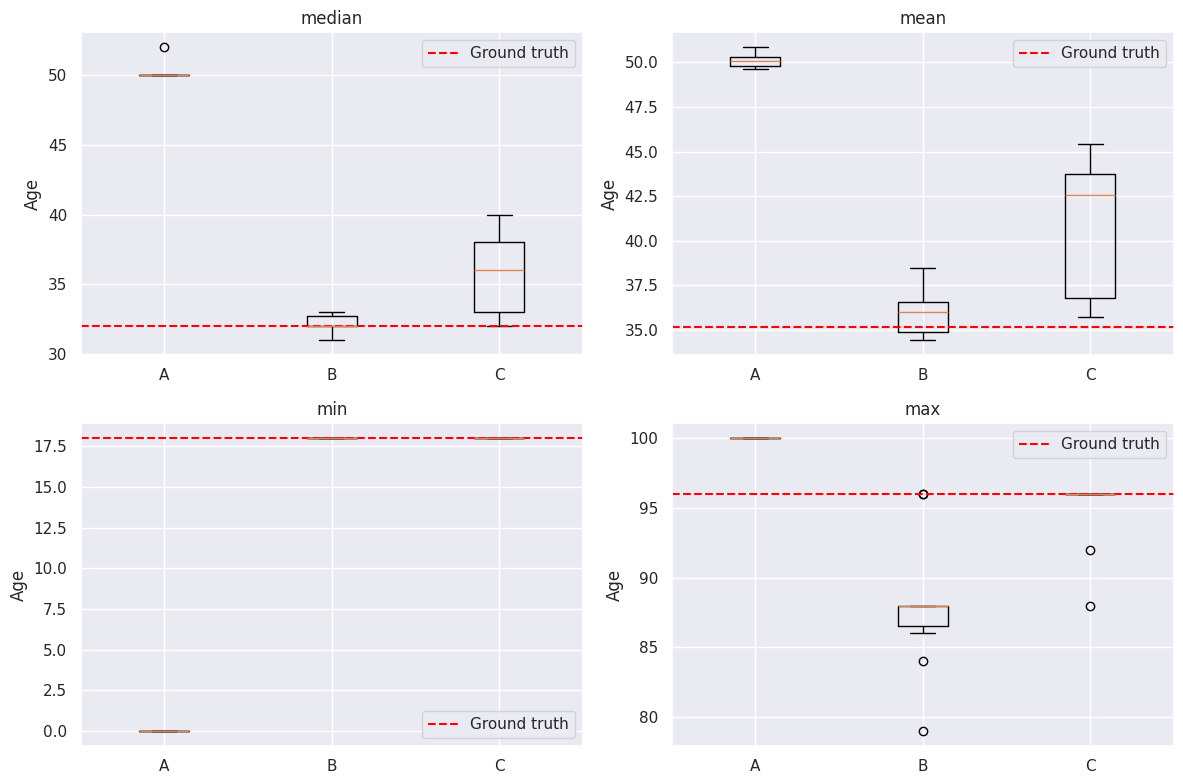

In [28]:
metrics = ["median", "mean", "min", "max"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    data = [
        results["A"][metric],
        results["B"][metric],
        results["C"][metric],
    ]

    axes[i].boxplot(data, labels=["A", "B", "C"])
    axes[i].axhline(gt[metric], color='red', linestyle='--', label="Ground truth")
    axes[i].set_title(metric)
    axes[i].set_ylabel("Age")
    axes[i].legend()

plt.tight_layout()
plt.show()

## Part (c)

Study how accuracy of Q3 changes for case **C**, as you vary __epsilon__ = [0.01, 0.02, ..., 0.1].

In [35]:
# Your code here
epsilons = np.arange(0.01, 0.11, 0.01)

methods = ["B", "C", "D"]

results = {
    "B": [],
    "C": [],
    "D": []
}

gt_race = df_real['race'].value_counts(normalize=True).sort_index()
mi_results = []

In [36]:
def mi_difference_sum(real_df, synth_df):
    mi_real = pairwise_attributes_mutual_information(real_df)
    mi_synth = pairwise_attributes_mutual_information(synth_df)

    cols = real_df.columns
    total_diff = 0

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            c1 = cols[i]
            c2 = cols[j]
            total_diff += abs(mi_real.loc[c1, c2] - mi_synth.loc[c1, c2])

    return total_diff

In [44]:
for method in methods:
    method_results = []

    for e in epsilons:
        kl_list = []

        for seed in range(10):
            if method == "B":
                synth = generate_data_B(real_data_file, output_data_size, epsilon=e, seed=seed)
            elif method == "C":
                synth = generate_data_C(real_data_file, output_data_size, epsilon=e, seed=seed)
            elif method == "D":
                synth = generate_data_D(real_data_file, output_data_size, epsilon=e, seed=seed)


            kl = kl_test(df_real, synth, "race")
            kl_list.append(kl)

            diff = mi_difference_sum(df_real, synth)
            mi_results.append({
                    "method": method,
                    "epsilon": e,
                    "seed": seed,
                    "mi_diff": diff
                })

        method_results.append(kl_list)

    results[method] = method_results

================ Constructing Bayesian Network (BN) ================
Adding ROOT age
Adding attribute score
Adding attribute race
Adding attribute sex
========================== BN constructed ==========================
================ Constructing Bayesian Network (BN) ================
Adding ROOT age
Adding attribute race
Adding attribute score
Adding attribute sex
========================== BN constructed ==========================
================ Constructing Bayesian Network (BN) ================
Adding ROOT sex
Adding attribute race
Adding attribute age
Adding attribute score
========================== BN constructed ==========================
================ Constructing Bayesian Network (BN) ================
Adding ROOT age
Adding attribute race
Adding attribute score
Adding attribute sex
========================== BN constructed ==========================
================ Constructing Bayesian Network (BN) ================
Adding ROOT age
Adding attribute score
Adding attri

In [45]:
mi_results_df = pd.DataFrame(mi_results)
mi_results_df.head()

,method,epsilon,seed,mi_diff
0,B,0.01,0,0.099473
1,B,0.01,1,0.102580
2,B,0.01,2,0.099857
3,B,0.01,3,0.099890
4,B,0.01,4,0.103566


In [46]:
results["B"]

[[np.float64(0.01138709184056032),
  np.float64(0.03789364930573743),
  np.float64(0.022743279452053698),
  np.float64(0.011819829778018365),
  np.float64(0.11058177616451574),
  np.float64(0.2674910788626014),
  np.float64(0.14741082334112857),
  np.float64(0.11250836029362558),
  np.float64(0.19390140919541932),
  np.float64(0.12048953167411616)],
 [np.float64(0.008876364306582606),
  np.float64(0.012874569444418924),
  np.float64(0.008695946183649406),
  np.float64(0.009266294137329925),
  np.float64(0.02898407581784354),
  np.float64(0.18632650339777923),
  np.float64(0.04400229625891036),
  np.float64(0.10475304686057335),
  np.float64(0.07797036965446728),
  np.float64(0.07662787625603346)],
 [np.float64(0.008627861633515296),
  np.float64(0.010270865909411979),
  np.float64(0.006000970426635352),
  np.float64(0.008890530851889508),
  np.float64(0.017421490696264003),
  np.float64(0.06496249669647867),
  np.float64(0.021237785879551323),
  np.float64(0.10346886612728452),
  np.fl

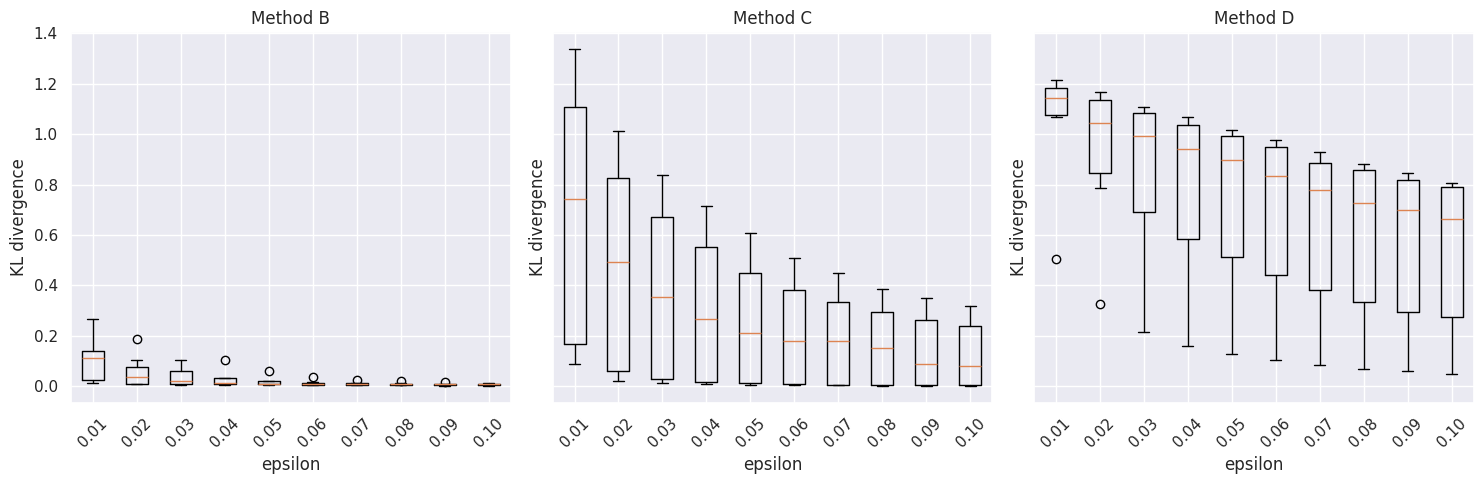

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

for i, method in enumerate(methods):
    axes[i].boxplot(results[method], positions=range(len(epsilons)))
    axes[i].set_title(f"Method {method}")
    axes[i].set_xticks(range(len(epsilons)))
    axes[i].set_xticklabels([f"{e:.2f}" for e in epsilons], rotation=45)
    axes[i].set_xlabel("epsilon")
    axes[i].set_ylabel("KL divergence")

plt.tight_layout()
plt.show()

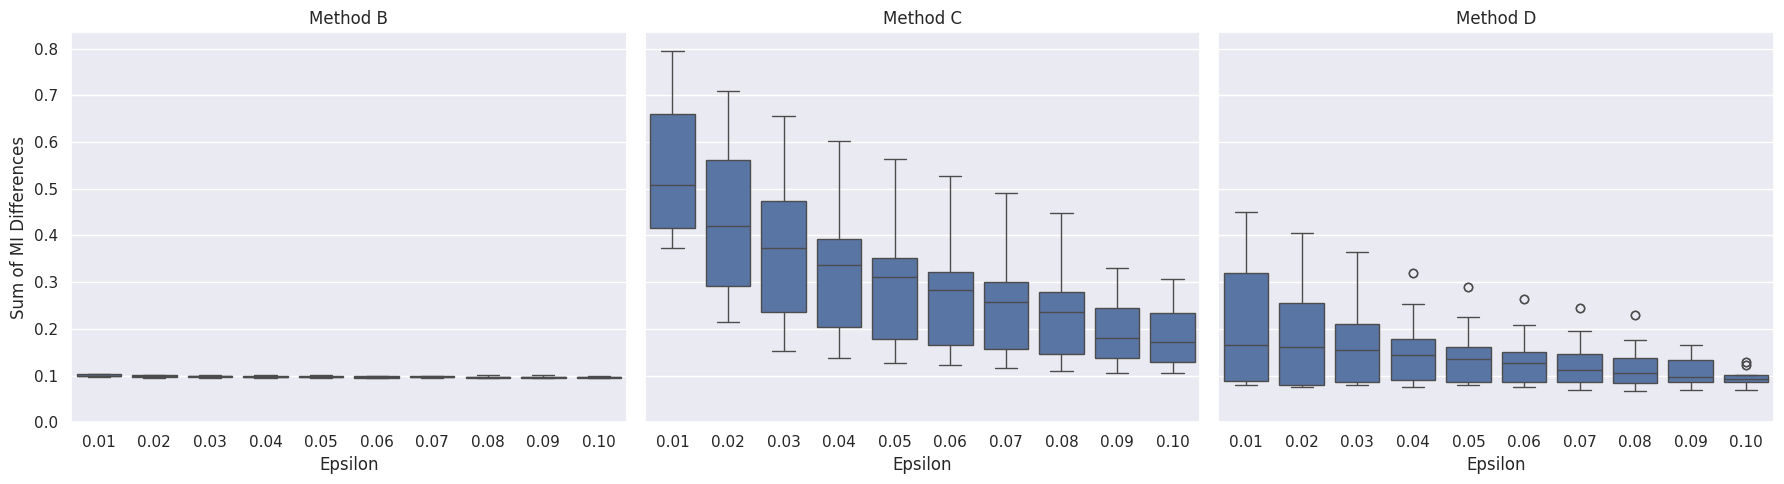

In [50]:
mi_results_df["epsilon_label"] = mi_results_df["epsilon"].map(lambda x: f"{x:.2f}")
ymax = mi_results_df["mi_diff"].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, method in zip(axes, methods):
    subset = mi_results_df[mi_results_df["method"] == method]

    sns.boxplot(
        data=subset,
        x="epsilon_label",
        y="mi_diff",
        ax=ax
    )

    ax.set_title(f"Method {method}")
    ax.set_xlabel("Epsilon")
    ax.set_ylabel("Sum of MI Differences")
    ax.set_ylim(0, ymax * 1.05)

plt.tight_layout()
plt.show()

In [52]:
for method in methods:

    for e in epsilons:

        for seed in range(10):
            if method == "B":
                synth = generate_data_B(fake_data_file, output_data_size, epsilon=e, seed=seed)
            elif method == "C":
                synth = generate_data_C(fake_data_file, output_data_size, epsilon=e, seed=seed)
            elif method == "D":
                synth = generate_data_D(fake_data_file, output_data_size, epsilon=e, seed=seed)


            diff = mi_difference_sum(df_fake, synth)
            mi_results.append({
                    "method": method,
                    "epsilon": e,
                    "seed": seed,
                    "mi_diff": diff
                })


================ Constructing Bayesian Network (BN) ================
Adding ROOT parent_2
Adding attribute child_2
Adding attribute child_1
Adding attribute parent_1
========================== BN constructed ==========================
================ Constructing Bayesian Network (BN) ================
Adding ROOT parent_2
Adding attribute child_1
Adding attribute child_2
Adding attribute parent_1
========================== BN constructed ==========================
================ Constructing Bayesian Network (BN) ================
Adding ROOT parent_1
Adding attribute child_1
Adding attribute parent_2
Adding attribute child_2
========================== BN constructed ==========================
================ Constructing Bayesian Network (BN) ================
Adding ROOT parent_2
Adding attribute child_1
Adding attribute child_2
Adding attribute parent_1
========================== BN constructed ==========================
================ Constructing Bayesian Network (BN) ========

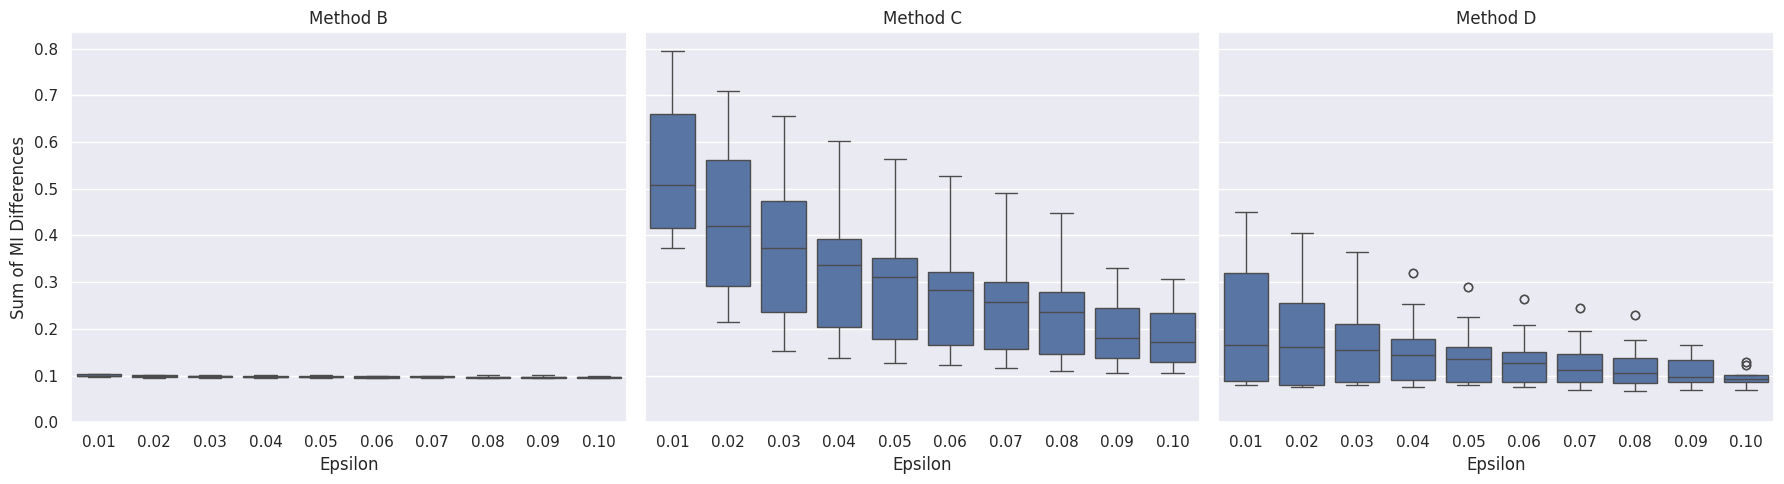

In [55]:
mi_results_df["epsilon_label"] = mi_results_df["epsilon"].map(lambda x: f"{x:.2f}")

ymax = mi_results_df["mi_diff"].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, method in zip(axes, methods):
    subset = mi_results_df[mi_results_df["method"] == method]

    sns.boxplot(
        data=subset,
        x="epsilon_label",
        y="mi_diff",
        ax=ax
    )

    ax.set_title(f"Method {method}")
    ax.set_xlabel("Epsilon")
    ax.set_ylabel("Sum of MI Differences")
    ax.set_ylim(0, ymax * 1.05)

plt.tight_layout()
plt.show()